In [8]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [9]:
class Lor_reservoir:
    def __init__(self, hyperparameters):
        self.num_neurons = hyperparameters.get("num_neurons")
        self.input_connectivity = hyperparameters.get("input_connectivity")
        self.num_steps = hyperparameters.get("num_steps")
        self.input_firing_rate = hyperparameters.get("input_firing_rate")
        self.weight_connectivity = hyperparameters.get("weight_connectivity")
        self.LIF_beta = hyperparameters.get("LIF_beta")
        self.LIF_threshold = hyperparameters.get("LIF_threshold")
        

    def init_weights(self, target_sr):

        # weight matrix for reservoir. Weights drawn from gaussian with mean 0 and std 0.333s, and with 10% connectivity.
        # includes exitatory and inhibitory weights.
        w_res = np.random.normal(0, 0.333, (self.num_neurons, self.num_neurons))

        mask = np.random.rand(self.num_neurons, self.num_neurons) < self.weight_connectivity
        w_res = w_res * mask
        np.fill_diagonal(w_res, 0) # no self-connections

        eigenvalues = np.linalg.eigvals(w_res)
        current_sr = np.max(np.abs(eigenvalues))

        #TODO more on this
        if current_sr > 0: 
            w_res = w_res / current_sr * target_sr

        print(f"initiating weights with spetral radius {target_sr}")

        return w_res
        

    def init_input_weights_full(self, input_dim):
        # shape: (num_neurons, input_dim)
        # random signs and magnitudes, sparse by input_connectivity
        w_in = np.random.uniform(-1, 1, (self.num_neurons, input_dim))
        mask = np.zeros((self.num_neurons, input_dim))
        input_neurons = np.random.choice(
            self.num_neurons,
            size=int(self.num_neurons * self.input_connectivity),
            replace=False
        )
        mask[input_neurons, :] = 1.0
        return w_in * mask

    def gen_spikes(self, rate_tensor):
        random_vals = np.random.random(rate_tensor.shape)
        spikes = (random_vals < rate_tensor).astype(float)
        return spikes
    

    def LIF_res(self, prev_mem, prev_spk, w_res, input_spikes, beta, threshold):

        recurrent_input = w_res @ prev_spk  # (num_neurons,)
        
        total_input = input_spikes + recurrent_input # (num_neurons,)

        spk = (prev_mem > threshold).astype(float)
        mem = beta * prev_mem + total_input - spk * threshold
        
        return mem, spk

In [10]:
def generate_lorenz(num_steps, dt=0.01, sigma=10, rho=28, beta=8/3):
    xyz = np.zeros((num_steps, 3))
    xyz[0] = [1.0, 1.0, 1.0]  # initial condition
    for t in range(num_steps - 1):
        x, y, z = xyz[t]
        dx = sigma * (y - x)
        dy = x * (rho - z) - y
        dz = x * y - beta * z
        xyz[t+1] = xyz[t] + dt * np.array([dx, dy, dz])
    return xyz

In [11]:
def train_readout_ridge(X_train, Y_train, alpha=1e-4):

    # X_train: (T, N)
    # Y_train: (T, 3)
    T, N = X_train.shape
    w_out = Y_train.T @ X_train @ np.linalg.inv(X_train.T @ X_train + alpha * np.eye(N))
    return w_out  # (3, N)

In [12]:
def nrmse(y_true, y_pred):
    # y_true, y_pred: (T, 3)
    error = np.sqrt(np.mean((y_true - y_pred)**2, axis=0))
    scale = np.std(y_true, axis=0)
    return error / scale  # (3,) — one per coordinate

In [13]:
washout_steps = 200
train_steps   = 700
test_steps    = 300
total_steps   = washout_steps + train_steps + test_steps  # 1200


hp = {
    "num_steps": total_steps,
    "num_neurons": 100,
    "input_firing_rate": 0.4,
    "input_connectivity": 0.3,
    "weight_connectivity": 0.1,
    "LIF_beta": 0.8187,
    "LIF_threshold": 1.0,
}


num_neurons = hp['num_neurons']
num_steps = hp['num_steps']

res = Lor_reservoir(hp)

spectral_lambdas = [0.5, 0.7, 0.9, 1.0, 1.1, 1.3, 1.5]

score_arr = []


for lam in spectral_lambdas:
    print(10*"#")
    print(f"for sr lambda {lam}")

    w_in_weights = res.init_input_weights_full(3) # (num_neurons, 3)
    w_res = res.init_weights(lam)

    lorenz_traj = generate_lorenz(num_steps, dt=0.01) # (num_steps, 3)

    mem = np.zeros(num_neurons)
    spk = np.zeros(num_neurons)
    spk_rec = np.zeros((num_steps, num_neurons))
    mem_rec = np.zeros((num_steps, num_neurons))

    print(f"ready to sim")

    for t in range(num_steps):

        I = w_in_weights @ lorenz_traj[t] # (100, )

        mem, spk = res.LIF_res(mem, spk, w_res, I, hp["LIF_beta"], hp["LIF_threshold"])
        spk_rec[t] = spk
        mem_rec[t] = mem


    X_train = spk_rec[washout_steps : washout_steps + train_steps]    # (T, N)
    Y_train = lorenz_traj[washout_steps+1 : washout_steps + train_steps+1]  # (T, 3)

    X_test = spk_rec[washout_steps + train_steps : total_steps - 1]   # (T, N)
    Y_test = lorenz_traj[washout_steps + train_steps+1 : total_steps]  # (T, 3)

    print(f"ready to train")

    # train
    w_out = train_readout_ridge(X_train, Y_train, alpha=1e-4)  # (3, N)

    # predict
    Y_pred = (w_out @ X_test.T).T   # (T, 3)

    # score
    scores = nrmse(Y_test, Y_pred)

    #print(f"for lam: {lam}, NRMSE  x:{scores[0]:.3f}  y:{scores[1]:.3f}  z:{scores[2]:.3f}")
    score_arr.append(scores)



##########
for sr lambda 0.5
initiating weights with spetral radius 0.5
ready to sim
ready to train
##########
for sr lambda 0.7
initiating weights with spetral radius 0.7
ready to sim
ready to train
##########
for sr lambda 0.9
initiating weights with spetral radius 0.9
ready to sim
ready to train
##########
for sr lambda 1.0
initiating weights with spetral radius 1.0
ready to sim
ready to train
##########
for sr lambda 1.1
initiating weights with spetral radius 1.1
ready to sim
ready to train
##########
for sr lambda 1.3
initiating weights with spetral radius 1.3
ready to sim
ready to train
##########
for sr lambda 1.5
initiating weights with spetral radius 1.5
ready to sim
ready to train


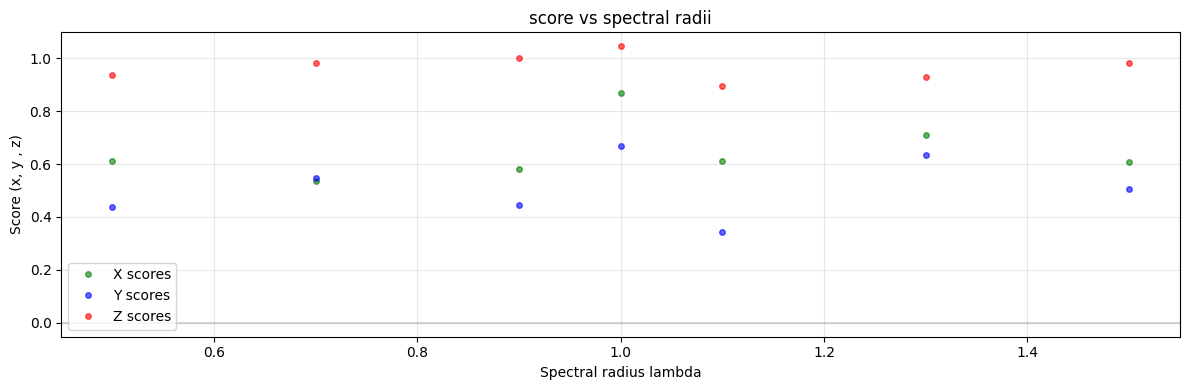

In [14]:
# Create visualization
plt.figure(figsize=(12, 4))

# Plot 1: Scatter plot of all samples
plt.plot(spectral_lambdas, [x[0] for x in score_arr], 'o', alpha=0.6, markersize=4, color="green", label='X scores')
plt.plot(spectral_lambdas, [y[1] for y in score_arr], 'o', alpha=0.6, markersize=4, color="blue", label='Y scores')
plt.plot(spectral_lambdas, [z[2] for z in score_arr], 'o', alpha=0.6, markersize=4, color="red", label='Z scores')

plt.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
plt.xlabel('Spectral radius lambda')
plt.ylabel('Score (x, y , z)')
plt.title('score vs spectral radii')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [15]:
hp = {
    "num_steps": total_steps,
    "num_neurons": 100,
    "input_firing_rate": 0.4,
    "input_connectivity": 0.3,
    "weight_connectivity": 0.1,
    "LIF_beta": 0.8187,
    "LIF_threshold": 1.0,
}


N = hp['num_neurons']
w_out = np.zeros((3, N))          # readout weights, start at zero
e_trace = np.zeros((3, N))        # eligibility trace, one per synapse


res = Lor_reservoir(hp)


w_res = res.init_weights(0.9)
w_in_weights = res.init_input_weights_full(3)

lorenz_traj = generate_lorenz(num_steps, dt=0.01)

washout_steps = 200
train_steps = 700

lr = 1e-3
gamma = 0.8


mem = np.zeros(N)
spk = np.zeros(N)
errors = []

for t in range(washout_steps + train_steps):
    # step reservoir
    I = w_in_weights @ lorenz_traj[t]
    mem, spk = res.LIF_res(mem, spk, w_res, I, hp['LIF_beta'], hp['LIF_threshold'])

    if t < washout_steps:
        continue

    # forward pass through readout
    r = spk                            # presynaptic activity (N,)
    y_pred = w_out @ r                 # postsynaptic output (3,)
    y_true = lorenz_traj[t + 1]        # target (3,)
    error = y_pred - y_true            # global learning signal (3,)

    # update eligibility trace (local: post × pre)
    e_trace = gamma * e_trace + np.outer(y_pred, r)

    # weight update: global error × local trace
    w_out -= lr * np.outer(error, np.ones(N)) * e_trace

    errors.append(np.mean(error**2))



initiating weights with spetral radius 0.9


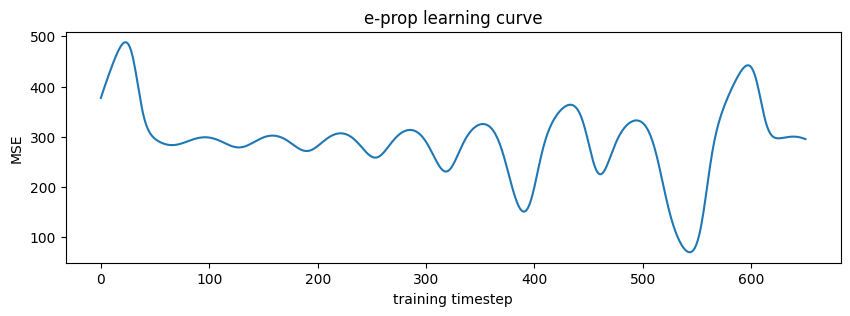

In [16]:
plt.figure(figsize=(10, 3))
plt.plot(np.convolve(errors, np.ones(50)/50, mode='valid'))  # smoothed
plt.xlabel('training timestep')
plt.ylabel('MSE')
plt.title('e-prop learning curve')
plt.show()